# Galaxy10 DECals Classification - Deep Learning Milestone 1

## Table of Contents

- [Imports](#Imports)
- [Load Data](#Load-Data)
- [Visualization of class distribution](#Visualization-of-class-distribution)
- [K-Fold Cross Validation](#K-Fold-Cross-Validation)

## Imports

In [23]:
%pip install "setuptools<70.0.0"
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold
import h5py
import math
from tensorflow.random import set_seed
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomBrightness, RandomContrast
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping, ReduceLROnPlateau
import os

Note: you may need to restart the kernel to use updated packages.


In [24]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Erfolg! {len(gpus)} GPU(s) gefunden.")
    for gpu in gpus:
        try:
            # Hier ist die kleine, aber wichtige Änderung: .experimental. hinzugefügt
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"Memory Growth für {gpu.name} erfolgreich aktiviert.")
        except RuntimeError as e:
            # Dieser Fehler wird geworfen, falls die GPU bereits von TF initialisiert wurde
            print(e)
else:
    print("Keine GPU gefunden.")

Erfolg! 1 GPU(s) gefunden.
Memory Growth für /physical_device:GPU:0 erfolgreich aktiviert.


## Load Data

In [25]:
data_path = './../data/Galaxy10_DECals.h5'

with h5py.File(data_path, 'r') as F:
    images_raw = np.array(F['images'])
    labels = np.array(F['ans'])

label_dict = {
    0: "Disturbed Galaxies",
    1: "Merging Galaxies",
    2: "Round Smooth Galaxies",
    3: "In-between Round Smooth Galaxies",
    4: "Cigar Shaped Smooth Galaxies",
    5: "Barred Spiral Galaxies",
    6: "Unbarred Tight Spiral Galaxies",
    7: "Unbarred Loose Spiral Galaxies",
    8: "Edge-on Galaxies without Bulge",
    9: "Edge-on Galaxies with Bulge"
}

# Labels liegen in der Datei nicht als One-Hot, sondern als einfache Indizes (0-9) vor
class_indices = labels

# Ausgabe
print(f"{'Klasse':<8} {'Beschreibung':<40} {'Anzahl':>7}")
print("-" * 58)

counts = {}
for cls_id, cls_name in label_dict.items():
    count = np.sum(class_indices == cls_id)
    counts[cls_id] = count
    print(f"{cls_id:<8} {cls_name:<40} {count:>7}")

print("-" * 58)
print(f"{'GESAMT':<48} {len(class_indices):>7}")

Klasse   Beschreibung                              Anzahl
----------------------------------------------------------
0        Disturbed Galaxies                          1081
1        Merging Galaxies                            1853
2        Round Smooth Galaxies                       2645
3        In-between Round Smooth Galaxies            2027
4        Cigar Shaped Smooth Galaxies                 334
5        Barred Spiral Galaxies                      2043
6        Unbarred Tight Spiral Galaxies              1829
7        Unbarred Loose Spiral Galaxies              2628
8        Edge-on Galaxies without Bulge              1423
9        Edge-on Galaxies with Bulge                 1873
----------------------------------------------------------
GESAMT                                             17736


## Visualization of class distribution

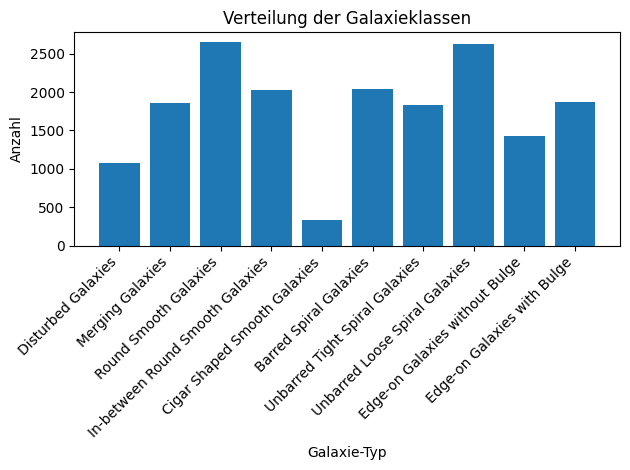

In [26]:
class_names = [label_dict[i] for i in label_dict.keys()]
values = [counts[i] for i in label_dict.keys()]

plt.figure()
plt.bar(range(len(values)), values)

plt.xticks(range(len(values)), class_names, rotation=45, ha='right')
plt.xlabel("Galaxie-Typ")
plt.ylabel("Anzahl")
plt.title("Verteilung der Galaxieklassen")

plt.tight_layout()
plt.show()

In [27]:
class RAMDataGenerator(Sequence):
    """Holt Bilder pfeilschnell aus dem RAM und formatiert sie on-the-fly."""
    def __init__(self, images_array, labels_array, indices, batch_size=32, num_classes=10):
        self.images = images_array
        self.labels = labels_array
        self.indices = indices
        self.batch_size = batch_size
        self.num_classes = num_classes
        
    def __len__(self):
        return math.ceil(len(self.indices) / self.batch_size)
        
    def __getitem__(self, idx):
        # Indizes für den aktuellen Batch berechnen
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        
        # Rohe uint8-Bilder aus dem RAM holen (sehr schnell!)
        batch_x = self.images[batch_indices]
        batch_y = self.labels[batch_indices]
            
        # HIER skaliert der Generator NUR diesen kleinen Batch (benötigt fast 0 RAM)
        batch_x = batch_x.astype(np.float32) / 255.0
        batch_y = to_categorical(batch_y, self.num_classes)
        
        return batch_x, batch_y

## K-Fold Cross Validation

In [28]:
# Reproduzierbarkeit
RANDOM_STATE = 42

# Labels (wie vorher)
y = class_indices

# --- 1. Test-Set abtrennen (einmal fix) ---
# We use indices so later folds refer to indices into X and y
X_temp, X_test, y_temp, y_test = train_test_split(
    np.arange(len(y)),  # indices
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train+Val: {len(X_temp)} | Test: {len(X_test)}")

# --- 2. K-Fold Cross Validation auf Train+Val ---
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

folds = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_temp, y_temp)):
    # train_idx/val_idx are positions within X_temp; convert to absolute indices
    train_indices = X_temp[train_idx]
    val_indices = X_temp[val_idx]

    folds.append((train_indices, val_indices))

    print(f"\nFold {fold_idx + 1}")
    print(f"Train: {len(train_indices)} | Val: {len(val_indices)}")

# Zugriff später:
# folds[0] → erstes (train, val)-Paar

Train+Val: 14188 | Test: 3548

Fold 1
Train: 11350 | Val: 2838

Fold 2
Train: 11350 | Val: 2838

Fold 3
Train: 11350 | Val: 2838

Fold 4
Train: 11351 | Val: 2837

Fold 5
Train: 11351 | Val: 2837


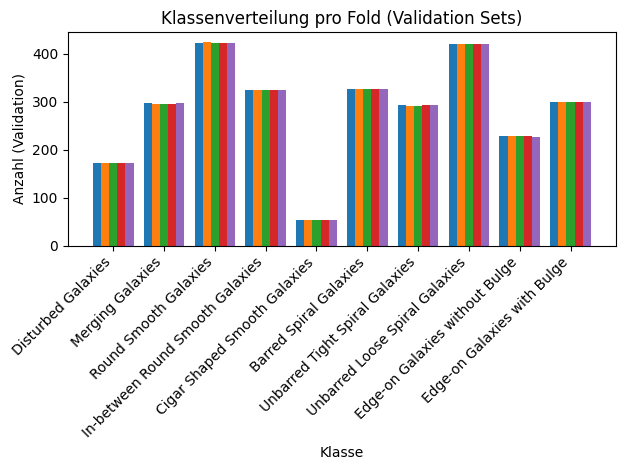

In [29]:
num_classes = len(label_dict)
k = len(folds)

# Matrix: [fold, klasse]
fold_class_counts = np.zeros((k, num_classes))

for fold_idx, (_, val_idx) in enumerate(folds):
    y_val = y[val_idx]
    for cls in range(num_classes):
        fold_class_counts[fold_idx, cls] = np.sum(y_val == cls)

# Plot
x = np.arange(num_classes)
width = 0.8 / k  # Balkenbreite abhängig von Anzahl Folds

plt.figure()

for fold_idx in range(k):
    plt.bar(x + fold_idx * width, fold_class_counts[fold_idx], width)

# Achsen & Labels
class_names = [label_dict[i] for i in range(num_classes)]
plt.xticks(x + width * (k - 1) / 2, class_names, rotation=45, ha='right')

plt.xlabel("Klasse")
plt.ylabel("Anzahl (Validation)")
plt.title("Klassenverteilung pro Fold (Validation Sets)")

plt.tight_layout()
plt.show()

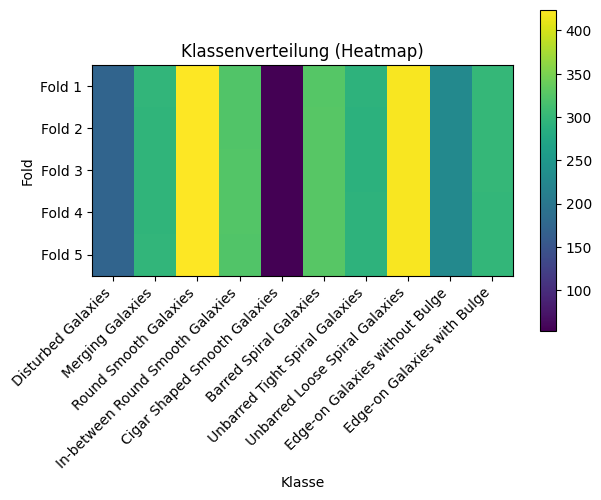

In [30]:
plt.figure()
plt.imshow(fold_class_counts)

plt.colorbar()
plt.xlabel("Klasse")
plt.ylabel("Fold")
plt.title("Klassenverteilung (Heatmap)")

plt.xticks(range(num_classes), [label_dict[i] for i in range(num_classes)], rotation=45, ha='right')
plt.yticks(range(k), [f"Fold {i+1}" for i in range(k)])

plt.tight_layout()
plt.show()

In [31]:
# Reproduzierbarkeit
SEED = 42
set_seed(SEED)
np.random.seed(SEED)

BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-4

NUM_CLASSES = len(label_dict)
# WICHTIG: Da wir X nicht mehr im RAM haben, setzen wir die Bildgröße manuell!
INPUT_SHAPE = (256, 256, 3) 

LOAD_MODELS = False  # Auf False setzen, wenn du neu trainieren willst

logs_dir = './../logs'
model_name="randomimageedits_conv9_samepadding_relu_batchnorm_maxpool_globalavg_reg_dropout05_dense2_softmax"
logs_dir += f"/{model_name}" if model_name else ""

os.makedirs(logs_dir, exist_ok=True)

# --- Modell-Builder ---
def build_model():
    model = Sequential([
        Input(shape=INPUT_SHAPE),

        RandomFlip("horizontal_and_vertical"),
        RandomRotation(0.2),
        RandomZoom(0.1),
        
        # Block 1
        Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(), # Hält die Signale im gesunden Bereich!
        Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Block 2
        Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Block 3
        Conv2D(128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Block 4
        Conv2D(256, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(256, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Block 5
        Conv2D(512, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        GlobalAveragePooling2D(),
        
        # Klassifikator
        Dense(256, activation='relu'),
        Dropout(0.5), 
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LR),
        loss="categorical_crossentropy", # Geändert auf categorical, da wir One-Hot-Encoding nutzen!
        metrics=["accuracy"]
    )
    return model

build_model().summary()

# --- Training pro Fold ---
def train_fold(fold_idx, train_idx, val_idx):
    fold_model = build_model()

    # Nutze nun den neuen RAMDataGenerator und übergebe die Variablen
    train_gen = RAMDataGenerator(images_raw, labels, train_idx, batch_size=BATCH_SIZE)
    val_gen = RAMDataGenerator(images_raw, labels, val_idx, batch_size=BATCH_SIZE)

    cp = ModelCheckpoint(
        filepath=f'{logs_dir}/checkpoint_fold{fold_idx + 1}.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=0
    )
    tb = TensorBoard(log_dir=f'{logs_dir}/fold{fold_idx + 1}')

    es = EarlyStopping(
        monitor='val_loss',        
        patience=8,                
        restore_best_weights=True, 
        verbose=1                  
    )

    lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1)

    history = fold_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        verbose=1,
        callbacks=[cp, tb, es, lr]
    )

    return fold_model, history

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 32, 32, 256)    │       590,08

 Total params: 2,492,202 (9.51 MB)

 Trainable params: 2,489,258 (9.50 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [32]:
fold_models = []
fold_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    checkpoint_path = f'{logs_dir}/checkpoint_fold{fold_idx + 1}.keras'
    
    # Prüfe: Sollen wir laden UND existiert die Datei?
    if LOAD_MODELS and os.path.exists(checkpoint_path):
        print(f"\n===== Fold {fold_idx + 1} / {len(folds)}: Lade gespeichertes Modell =====")
        # Modell direkt aus der Datei laden
        _model = tf.keras.models.load_model(checkpoint_path)
        # Da wir nicht trainieren, gibt es kein neues 'history' Objekt
        history = None 
        print(f"✓ Modell erfolgreich aus {checkpoint_path} geladen.")
    else:
        print(f"\n===== Fold {fold_idx + 1} / {len(folds)}: Starte neues Training =====")
        # Die ursprüngliche Funktion aufrufen
        _model, history = train_fold(fold_idx, train_idx, val_idx)
        
    fold_models.append(_model)
    fold_histories.append(history)

print("\n✓ Alle Folds bereit.")


===== Fold 1 / 5: Starte neues Training =====
Epoch 1/30


/home/alexa/Projects/deep-learning/tf-gpu-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


710/710 ━━━━━━━━━━━━━━━━━━━━ 103s 137ms/step - accuracy: 0.3189 - loss: 1.8966 - val_accuracy: 0.3199 - val_loss: 1.8439 - learning_rate: 1.0000e-04
Epoch 2/30
710/710 ━━━━━━━━━━━━━━━━━━━━ 98s 138ms/step - accuracy: 0.4744 - loss: 1.4927 - val_accuracy: 0.5035 - val_loss: 1.4529 - learning_rate: 1.0000e-04
Epoch 3/30
710/710 ━━━━━━━━━━━━━━━━━━━━ 98s 137ms/step - accuracy: 0.5808 - loss: 1.2276 - val_accuracy: 0.5370 - val_loss: 1.3985 - learning_rate: 1.0000e-04
Epoch 4/30
710/710 ━━━━━━━━━━━━━━━━━━━━ 98s 138ms/step - accuracy: 0.6367 - loss: 1.0733 - val_accuracy: 0.6378 - val_loss: 1.0800 - learning_rate: 1.0000e-04
Epoch 5/30
710/710 ━━━━━━━━━━━━━━━━━━━━ 97s 137ms/step - accuracy: 0.6751 - loss: 0.9567 - val_accuracy: 0.6180 - val_loss: 1.1322 - learning_rate: 1.0000e-04
Epoch 6/30
710/710 ━━━━━━━━━━━━━━━━━━━━ 98s 138ms/step - accuracy: 0.7056 - loss: 0.8840 - val_accuracy: 0.6959 - val_loss: 0.9377 - learning_rate: 1.0000e-04
Epoch 7/30
710/710 ━━━━━━━━━━━━━━━━━━━━ 97s 137ms/step -

In [33]:
test_accuracies = []

print("Starte Evaluierung auf dem Test-Set...")

test_gen = RAMDataGenerator(images_raw, labels, X_test, batch_size=BATCH_SIZE)

for i, fold_model in enumerate(fold_models):
    print(f"\nEvaluiere Modell aus Fold {i + 1}...")
    
    # 2. verbose=1 schaltet den Keras-Ladebalken ein, damit du siehst, dass etwas passiert!
    loss, acc = fold_model.evaluate(test_gen, verbose=1) 
    
    test_accuracies.append(acc)
    print(f"-> Ergebnis Fold {i + 1} - Test Accuracy: {acc:.4f}")

print(f"\n{'='*40}")
print(f"Durchschnittliche Test Accuracy: {np.mean(test_accuracies):.4f}")
print(f"Standardabweichung:              {np.std(test_accuracies):.4f}")
print(f"{'='*40}")

Starte Evaluierung auf dem Test-Set...

Evaluiere Modell aus Fold 1...
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8202 - loss: 0.5559
-> Ergebnis Fold 1 - Test Accuracy: 0.8202

Evaluiere Modell aus Fold 2...
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8055 - loss: 0.5895
-> Ergebnis Fold 2 - Test Accuracy: 0.8055

Evaluiere Modell aus Fold 3...
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8086 - loss: 0.5838
-> Ergebnis Fold 3 - Test Accuracy: 0.8086

Evaluiere Modell aus Fold 4...
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8213 - loss: 0.5404
-> Ergebnis Fold 4 - Test Accuracy: 0.8213

Evaluiere Modell aus Fold 5...
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8264 - loss: 0.5398
-> Ergebnis Fold 5 - Test Accuracy: 0.8264

Durchschnittliche Test Accuracy: 0.8164
Standardabweichung:              0.0080


GEWINNER-MODELL: Fold 5
Test-Accuracy:   0.8264 (82.64 %)

Erstelle Confusion Matrix für das beste Modell...
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step


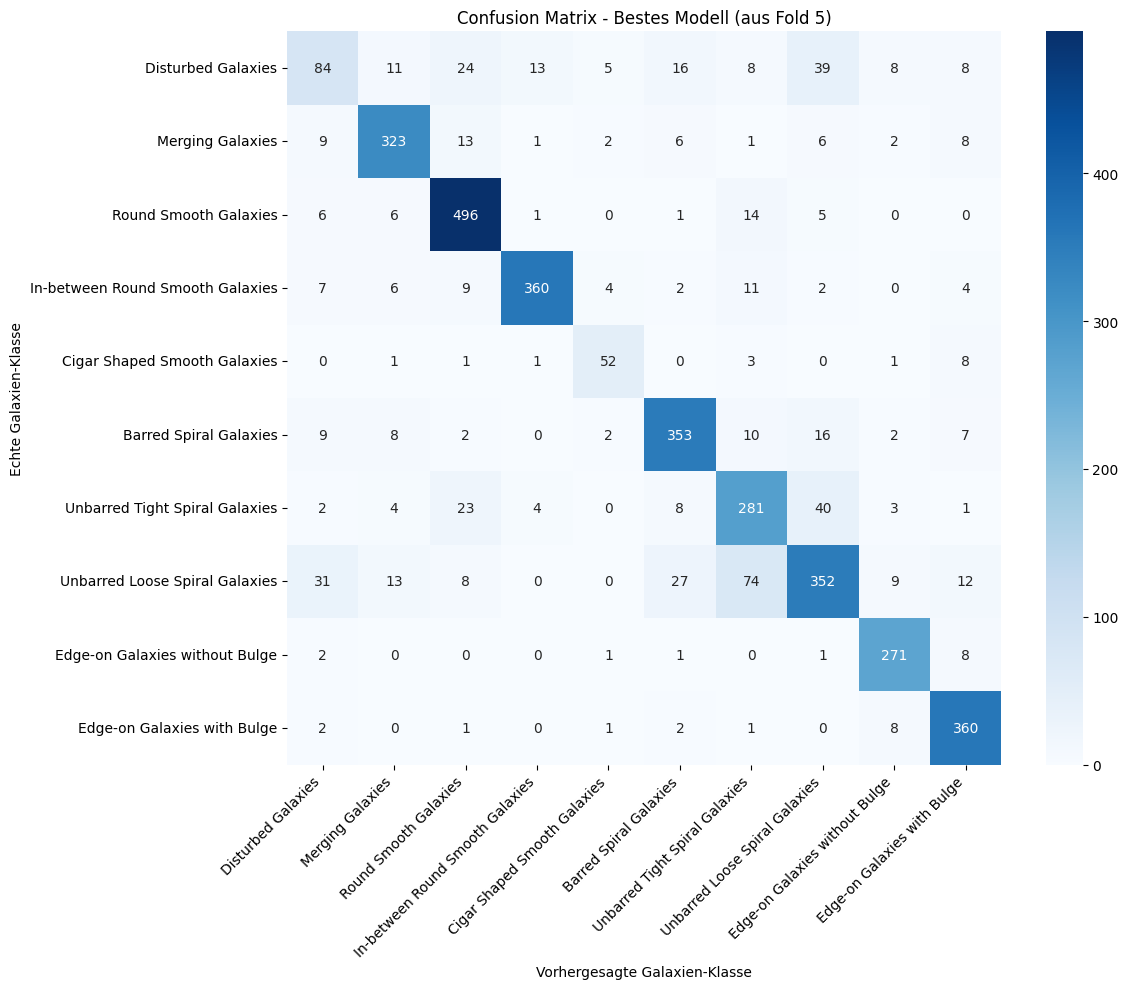

In [34]:
# 1. Den Gewinner ermitteln!
# np.argmax sucht uns automatisch den Index des höchsten Wertes in deiner Test-Accuracy-Liste
best_fold_idx = np.argmax(test_accuracies)
best_model = fold_models[best_fold_idx]

print(f"{'='*58}")
print(f"GEWINNER-MODELL: Fold {best_fold_idx + 1}")
print(f"Test-Accuracy:   {test_accuracies[best_fold_idx]:.4f} ({(test_accuracies[best_fold_idx]*100):.2f} %)")
print(f"{'='*58}\n")

print("Erstelle Confusion Matrix für das beste Modell...")

# 2. Vorhersagen NUR mit dem Gewinner-Modell machen
# Das test_gen Objekt haben wir ja eine Zelle drüber bereits erstellt
predictions = best_model.predict(test_gen)

# 3. Höchste Wahrscheinlichkeit als finale Antwort wählen
y_pred = np.argmax(predictions, axis=1)
y_true = y[X_test]

# 4. Matrix berechnen
cm = confusion_matrix(y_true, y_pred)

# 5. Plotten
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_dict[i] for i in range(NUM_CLASSES)],
            yticklabels=[label_dict[i] for i in range(NUM_CLASSES)])

plt.title(f"Confusion Matrix - Bestes Modell (aus Fold {best_fold_idx + 1})")
plt.ylabel("Echte Galaxien-Klasse")
plt.xlabel("Vorhergesagte Galaxien-Klasse")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()